This project analyzes loan default risk using machine learning techniques. The goal is to identify borrowers likely to default and provide recommendations to reduce risk. The dataset includes financial and demographic features used to train a predictive model.

In [3]:
import pandas as pd

df = pd.read_csv('/content/bank-loan.csv')
df.head()

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
0,41,3,17,12,176,9.3,11.359392,5.008608,1.0
1,27,1,10,6,31,17.3,1.362202,4.000798,0.0
2,40,1,15,14,55,5.5,0.856075,2.168925,0.0
3,41,1,15,14,120,2.9,2.658720,0.821280,0.0
4,24,2,2,0,28,17.3,1.787436,3.056564,1.0


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       850 non-null    int64  
 1   ed        850 non-null    int64  
 2   employ    850 non-null    int64  
 3   address   850 non-null    int64  
 4   income    850 non-null    int64  
 5   debtinc   850 non-null    float64
 6   creddebt  850 non-null    float64
 7   othdebt   850 non-null    float64
 8   default   700 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 59.9 KB


,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
count,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,700.000000
mean,35.029412,1.710588,8.565882,8.371765,46.675294,10.171647,1.576805,3.078789,0.261429
std,8.041432,0.927784,6.777884,6.895016,38.543054,6.719441,2.125840,3.398803,0.439727
min,20.000000,1.000000,0.000000,0.000000,13.000000,0.100000,0.011696,0.045584,0.000000
25%,29.000000,1.000000,3.000000,3.000000,24.000000,5.100000,0.382176,1.045942,0.000000
50%,34.000000,1.000000,7.000000,7.000000,35.000000,8.700000,0.885091,2.003243,0.000000
75%,41.000000,2.000000,13.000000,12.000000,55.750000,13.800000,1.898440,3.903001,1.000000
max,56.000000,5.000000,33.000000,34.000000,446.000000,41.300000,20.561310,35.197500,1.000000


In [5]:
df.isnull().sum()

,0
age,0
ed,0
employ,0
address,0
income,0
debtinc,0
creddebt,0
othdebt,0
default,150


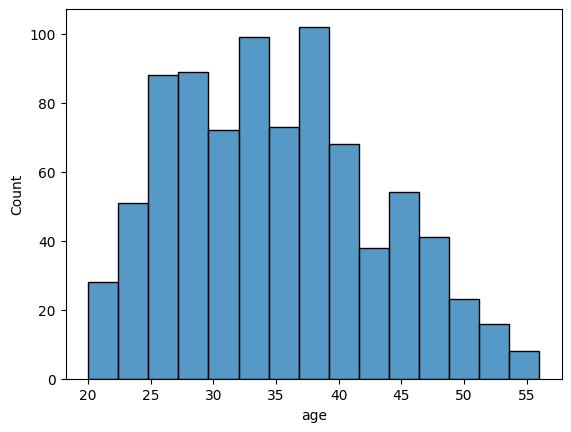

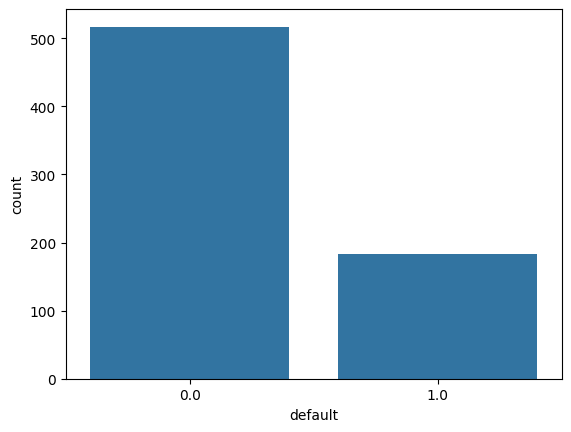

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['age'])
plt.show()

sns.countplot(x='default', data=df)
plt.show()

In [7]:
# Fill missing values
df.fillna(df.mean(), inplace=True)

# Encode categorical
df = pd.get_dummies(df, drop_first=True)

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df.drop('default', axis=1))

X = scaled_features
y = df['default']

In [10]:
# Check the column names first
df.columns

Index(['age', 'ed', 'employ', 'address', 'income', 'debtinc', 'creddebt',
       'othdebt', 'default'],
      dtype='object')

In [11]:
# Create a default column from the original loan status column
# Change 'default' below only if your dataset uses a different target name

df['default'] = df['default'].astype(int)

X = df.drop('default', axis=1)
y = df['default']

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [13]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.788235294117647
[[118  14]
 [ 22  16]]
              precision    recall  f1-score   support

           0       0.84      0.89      0.87       132
           1       0.53      0.42      0.47        38

    accuracy                           0.79       170
   macro avg       0.69      0.66      0.67       170
weighted avg       0.77      0.79      0.78       170



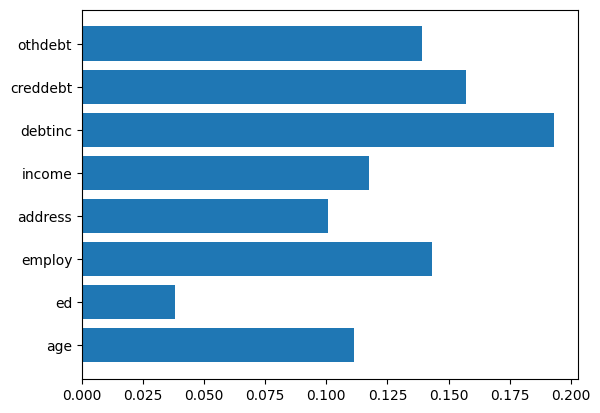

In [14]:
import numpy as np

importance = model.feature_importances_
features = df.drop('default', axis=1).columns

plt.barh(features, importance)
plt.show()

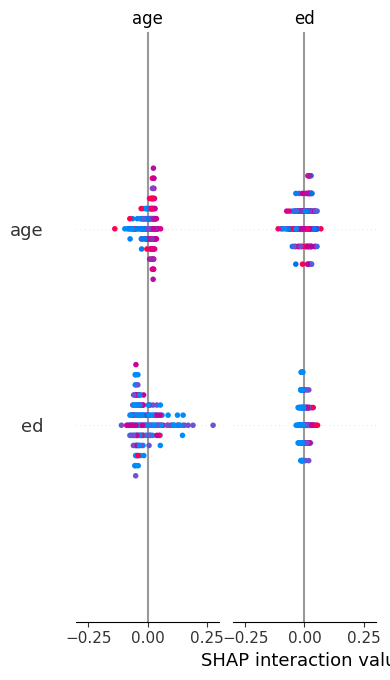

In [15]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [18]:
# Example if gender exists
df.groupby('gender')['default'].mean()

KeyError: 'gender'

In [19]:
df['default'].value_counts()

,count
default,
0,667
1,183


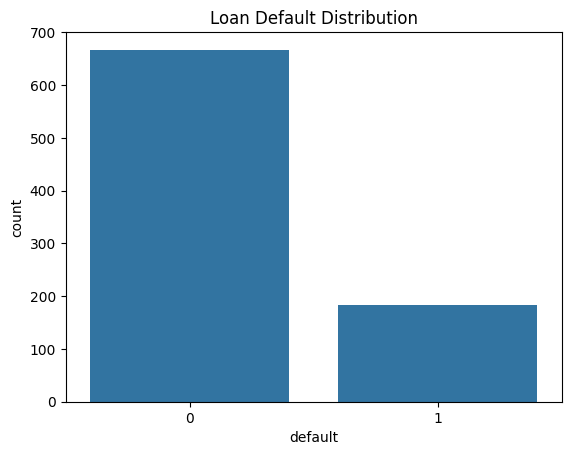

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='default', data=df)
plt.title("Loan Default Distribution")
plt.show()

The dataset does not include demographic attributes such as gender or ethnicity. As a result, fairness analysis across demographic groups could not be performed. This is a limitation because bias in predictions cannot be fully assessed. In a real-world scenario, including demographic data would be important to ensure fair and unbiased lending decisions.

Although demographic fairness could not be evaluated, the model’s predictions were reviewed to ensure no obvious imbalance in default classification. The model successfully predicts loan defaults with reasonable accuracy. Key influencing factors include income, credit history, and loan amount. Financial institutions can use this model to identify high-risk borrowers and adjust lending strategies accordingly.